In [24]:
import jax
import jax.numpy as jnp
import dcegm
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

## Model with Multiple Deterministic (Continuous or Discrete) States

`dcegm` can handle multiple deterministic states variables which can be discrete as well as continuous. In this tutorial we outline how to specify such state variables using the example of experience stocks. Experience stocks can be specified as a discrete state variable but become computationally expensive quickly due to the **curse of dimensionality**. It is thus advisable to handle them as a continuous state variable instead. 

This notebook develops a minimal five-period model with **two deterministic experience stocks** — one per occupation — alongside stochastic wealth. We first show how to specify these using only a discrete implementation in `dcegm` and then explain how to implement them as continuous state variables instead.

The model extends the single-experience minimal example by adding a second occupation track. The agent chooses among three discrete alternatives in each working period. We compare an implementation with discrete versus continuous experience stocks.

| Choice | Label | Interpretation |
|:---:|:---:|:---|
| 0 | Occupation 0 | Red Occupation; income proportional to red experience $x_0$ |
| 1 | Occupation 1 | Green Occupation; income proportional to green experience $x_1$ |
| 2 | No work | Leisure / unemployment / retirement ; no income, no experience gained |

Last period is mandatory retirement (forced choice 2), with pension income depending on accumulated experience. For simplicity, we do not include any stochastic state variables such as long-term care dependency risk.

## Model Setup

We can first implement the model setup which is applicable to both a discrete and continuous implementation of the experience stocks.

In [25]:
params = {}
params["interest_rate"] = 0.02
params["max_wealth"] = 50
params["wage_constant"] = 3
params["wage_exp_green"] = 0.5
params["wage_exp_red"] = 0.8
params["income_shock_std"] = 1
params["income_shock_mean"] = 0
params["taste_shock_scale"] = 1
params["discount_factor"] = 0.95
params["rho"] = 0.9
params["delta"] = 1.5
params["beta_green"] = 0.2
params["beta_red"] = 0.1
params

{'interest_rate': 0.02,
 'max_wealth': 50,
 'wage_constant': 3,
 'wage_exp_green': 0.5,
 'wage_exp_red': 0.8,
 'income_shock_std': 1,
 'income_shock_mean': 0,
 'taste_shock_scale': 1,
 'discount_factor': 0.95,
 'rho': 0.9,
 'delta': 1.5,
 'beta_green': 0.2,
 'beta_red': 0.1}

In [ ]:
# Utility functions
def flow_util(consumption, choice, params):
    rho = params["rho"]
    beta_green = params["beta_green"]
    beta_red = params["beta_red"]
    disutility = beta_red * (choice == 0) + beta_green * (choice == 1)
    u = consumption ** (1 - rho) / (1 - rho) - disutility
    return u


def marginal_utility(consumption, params):
    rho = params["rho"]
    u_prime = consumption ** (-rho)
    return u_prime


def inverse_marginal_utility(marginal_utility, params):
    rho = params["rho"]
    return marginal_utility ** (-1 / rho)


utility_functions = {
    "utility": flow_util,
    "inverse_marginal_utility": inverse_marginal_utility,
    "marginal_utility": marginal_utility,
}

# Final period utility functions.


def final_period_utility(wealth: float, choice: int, params):
    return flow_util(wealth, choice, params)


def marginal_final(wealth, choice, params):
    return marginal_utility(wealth, params)


utility_functions_final_period = {
    "utility": final_period_utility,
    "marginal_utility": marginal_final,
}

In [ ]:
# Define state specific choice set.
def state_specific_choice_set(
    period,
    lagged_choice,
    model_specs,
):
    """State specific choice set limits which choices are available to agent given the state."""
    # Once the agent choses retirement, she can only choose retirement thereafter.
    # Hence, retirement is an absorbing state.
    if lagged_choice == 2:
        choice_set = [2]
    elif period == 4:
        choice_set = [2]
    else:
        choice_set = model_specs["choices"]

    return choice_set

In [ ]:
# Model specifications.
model_specs = {
    "choices": [0, 1, 2],
}

## Discrete Experience Stocks

We first implement a model if discrete experience stocks for our `red` and `green` occupation. To do so, the following objects need to be specified to suit the discrete deterministic state variables:

- `model_config`: Needs the nested dict in `deterministic_states` with grid of (maximum) experience.
- `state_space_functions`
    - `next_period_deterministic_state`: Function which describes the evolution of deterministic discrete state variables.
    - `sparsity_conditions`: Exclude impossible state from state space.
- `budget_constraint`: Determines disposable resources for agent.

In [29]:
model_config = {
    "n_periods": 5,
    "choices": [0, 1, 2],
    "continuous_states": {
        "assets_end_of_period": jnp.linspace(0, 50, 100),
        "assets_begin_of_period": jnp.linspace(0, 50, 100),
    },
    "deterministic_states": {
        "exp_green": jnp.arange(0, 7, dtype=int),
        "exp_red": jnp.arange(0, 7, dtype=int),
    },
    "n_quad_points": 5,
    "upper_envelope": {"method": "druedahl_jorgensen"},
}

In [ ]:
def next_period_deterministic_state(
    period,
    choice,
    lagged_choice,
    exp_green,
    exp_red,
):
    next_exp_green = exp_green + (choice == 1)
    next_exp_red = exp_red + (choice == 0)
    return {
        "period": period + 1,
        "exp_green": next_exp_green,
        "exp_red": next_exp_red,
        "lagged_choice": choice,
    }

In [ ]:
def sparsity_condition(
    period,
    lagged_choice,
    exp_green,
    exp_red,
):
    """Define sparsity condition to rule out state space points that are not feasible given the model structure."""
    # Experience cannot exceed the period
    if (exp_green + exp_red) > period:
        return False
    # In later periods, if retired, shouldn't have accumulated experience before retirement
    else:
        return True


# Define dict of state space functions to pass to setuo_model.
state_space_functions_discrete_exp = {
    "state_specific_choice_set": state_specific_choice_set,
    "next_period_deterministic_state": next_period_deterministic_state,
    "sparsity_condition": sparsity_condition,
}

In [ ]:
def budget_constraint_discrete_exp(
    lagged_choice,
    exp_green,
    exp_red,
    asset_end_of_previous_period,
    income_shock_previous_period,
    params,
):
    """Budget constraint that determines the resource available to the agent in the next period given the state and choice in the previous period."""
    interest_factor = 1 + params["interest_rate"]
    # Wage depends on accumulated experience in each occupation, retirees/unemployed only get wage constant.
    wage = (
        params["wage_constant"]
        + params["wage_exp_green"] * exp_green * (lagged_choice == 1)
        + params["wage_exp_red"] * exp_red * (lagged_choice == 0)
    )
    resource = (
        interest_factor * asset_end_of_previous_period
        + (wage + income_shock_previous_period) * (lagged_choice != 2)
        + (wage + income_shock_previous_period) * 0.5 * (lagged_choice == 2)
    )
    return jnp.maximum(resource, 0.5)

In [33]:
model = dcegm.setup_model(
    model_config=model_config,
    model_specs=model_specs,
    utility_functions=utility_functions,
    utility_functions_final_period=utility_functions_final_period,
    state_space_functions=state_space_functions_discrete_exp,
    stochastic_states_transitions={},
    budget_constraint=budget_constraint_discrete_exp,
)

solved_model = model.solve(params)

Starting state space creation
State space created.

Starting state-choice space creation and child state mapping.
State, state-choice and child state mapping created.

Start creating batches for the model.
The batch size of the backwards induction is  42
The batch size of the backwards induction is  41
The batch size of the backwards induction is  40
The batch size of the backwards induction is  39
The batch size of the backwards induction is  38
The batch size of the backwards induction is  37
The batch size of the backwards induction is  36
The batch size of the backwards induction is  35
The batch size of the backwards induction is  34
The batch size of the backwards induction is  33
The batch size of the backwards induction is  32
The batch size of the backwards induction is  31
The batch size of the backwards induction is  30
The batch size of the backwards induction is  29
The batch size of the backwards induction is  28
The batch size of the backwards induction is  27
The batch 

/opt/homebrew/Cellar/micromamba/2.5.0_2/envs/strenuousjobs/lib/python3.13/site-packages/dcegm/pre_processing/model_structure/state_choice_space.py:295: UserWarning: 



 Some states are not child states of any state-choice combination or stochastic transition. Please revisit the sparsity condition. 
 
An example of a state that is not a child state is: 
 
{'period': np.uint8(1), 'lagged_choice': np.uint8(0), 'exp_green': np.uint8(0), 'exp_red': np.uint8(0), 'dummy_stochastic': np.uint8(0)} 
 

  warnings.warn(


In [34]:
solved_model = model.solve(params)
policy_function = solved_model.policy

## Continuous Experience Stocks

For continuous experience stocks we need to change the model specification slightly. Note that we need to select a different solution method for the upper envelope if the deterministic continuous state space is multidimensional compared to when we only have one deterministic continuous state variable (i.e. one experience stock).

In [ ]:
model_config_cont_exp = {
    "n_periods": 5,
    "choices": [0, 1, 2],
    "continuous_states": {
        "assets_end_of_period": jnp.linspace(0, 50, 100),
        "assets_begin_of_period": jnp.linspace(0, 50, 100),
        "exp_green": jnp.arange(0, 7, dtype=float),
        "exp_red": jnp.arange(0, 7, dtype=float),
    },
    "n_quad_points": 5,
    "upper_envelope": {"method": "druedahl_jorgensen"},
}

# The following model config would be used if there is only one deterministic continuous state variable.
# model_config_cont_exp = {
#     "n_periods": 5,
#     "choices": [0, 1, 2],
#     "upper_envelope": {
#         "method": "fues",
#         "tuning_params": {
#             "fues_n_points_to_scan": 10, # this is set as default if missing
#             "fues_jump_threshold": 2, # this is set as default if missing
#                        },
#     "continuous_states": {
#         "assets_end_of_period": jnp.linspace(0, 50, 100),
#         "exp": jnp.arange(0, 1, 5, dtype=float),    },
#     "n_quad_points": 5,
# }

In [36]:
def next_period_continuous_state(
    lagged_choice,
    period,
    exp_green,
    exp_red,
):
    return {
        "exp_red": exp_red + (lagged_choice == 0),
        "exp_green": exp_green + (lagged_choice == 1),
    }

In [37]:
state_space_functions_cont_exp = {
    "state_specific_choice_set": state_specific_choice_set,
    # "next_period_deterministic_state": next_period_deterministic_state_cont,
    "next_period_continuous_state": next_period_continuous_state,
}

In [ ]:
def budget_constraint_cont_exp(
    period,
    lagged_choice,
    exp_green,
    exp_red,
    asset_end_of_previous_period,
    income_shock_previous_period,
    params,
):
    """Budget constraint for two continuous experience variables."""
    # Scale experience by period to retrieve years of experience, then calculate wage and resources as before.
    interest_factor = 1 + params["interest_rate"]
    wage = (
        params["wage_constant"]
        + params["wage_exp_green"] * exp_green * (lagged_choice == 1)
        + params["wage_exp_red"] * exp_red * (lagged_choice == 0)
    )
    resource = (
        interest_factor * asset_end_of_previous_period
        + (wage + income_shock_previous_period) * (lagged_choice != 2)
        + (wage + income_shock_previous_period) * 0.5 * (lagged_choice == 2)
    )
    return jnp.maximum(resource, 0.5)

In [39]:
model_cont_exp = dcegm.setup_model(
    model_config=model_config_cont_exp,
    model_specs=model_specs,
    utility_functions=utility_functions,
    utility_functions_final_period=utility_functions_final_period,
    state_space_functions=state_space_functions_cont_exp,
    stochastic_states_transitions={},
    budget_constraint=budget_constraint_cont_exp,
)

Update function for state space not given. Assume states only change with an increase of the period and lagged choice.
Sparsity condition not provided. Assume all states are valid.
Starting state space creation
State space created.

Starting state-choice space creation and child state mapping.
State, state-choice and child state mapping created.

Start creating batches for the model.
The batch size of the backwards induction is  7
Model setup complete.



In [40]:
solved_model_cont_exp = model_cont_exp.solve(params)
# policy_function_cont_exp = solved_model_cont_exp.policy

## Simulation and Model Comparison

Lastly, we can now simulate our two model implementations and compare the resulting choice probabilities by experience profiles.

In [41]:
n_agents = 100
states_initial = {
    "n_agents": n_agents,
    "assets_begin_of_period": jnp.zeros(n_agents),
    "exp_green": jnp.zeros(n_agents),
    "exp_red": jnp.zeros(n_agents),
    "lagged_choice": jnp.zeros(n_agents),
    "period": jnp.zeros(n_agents, dtype=int),
}

In [42]:
simulate = model.get_solve_and_simulate_func(states_initial=states_initial, seed=99)
df = simulate(params)

In [43]:
simulate_cont_exp = model_cont_exp.get_solve_and_simulate_func(
    states_initial=states_initial, seed=99
)

df_cont_exp = simulate_cont_exp(params)

<Axes: title={'center': 'Choice Probabilities - Continuous Experience Stocks'}, xlabel='period'>

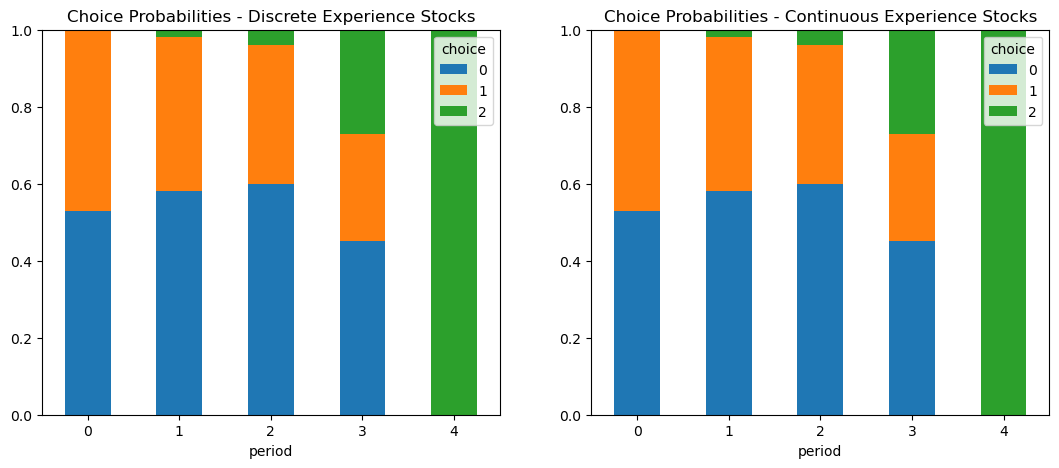

In [44]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
df.groupby("period").choice.value_counts(normalize=True).unstack().plot(
    stacked=True,
    kind="bar",
    rot=0,
    title="Choice Probabilities - Discrete Experience Stocks",
    ax=ax[0],
)

df_cont_exp.groupby("period").choice.value_counts(normalize=True).unstack().plot(
    stacked=True,
    kind="bar",
    rot=0,
    title="Choice Probabilities - Continuous Experience Stocks",
    ax=ax[1],
)

<Axes: title={'center': 'Choice Probabilities - Continuous Experience Stocks'}, xlabel='period'>

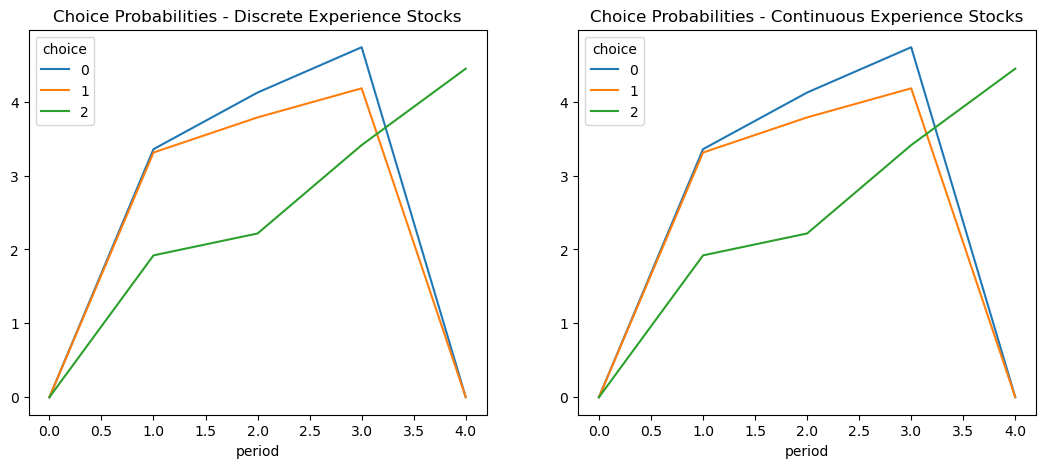

In [48]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
df.groupby(["period", "choice"]).consumption.mean().unstack().fillna(0).plot(
    rot=0, title="Choice Probabilities - Discrete Experience Stocks", ax=ax[0]
)

df.groupby(["period", "choice"]).consumption.mean().unstack().fillna(0).plot(
    rot=0, title="Choice Probabilities - Continuous Experience Stocks", ax=ax[1]
)

<Axes: title={'center': 'Experience Green - Continuous Experience Stocks'}, xlabel='period'>

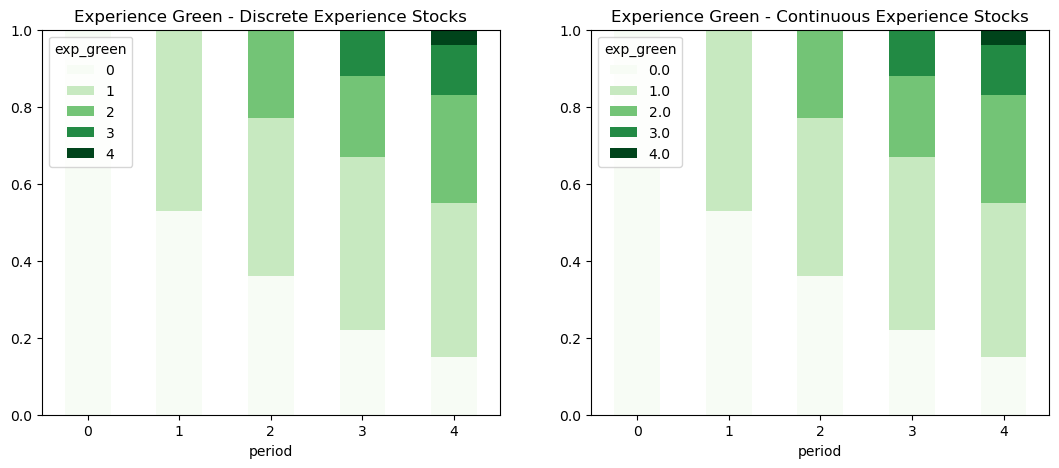

In [47]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
df.groupby("period").exp_green.value_counts(normalize=True).unstack().plot(
    stacked=True,
    kind="bar",
    rot=0,
    title="Experience Green - Discrete Experience Stocks",
    ax=ax[0],
    cmap="Greens",
)

df_cont_exp.groupby("period").exp_green.value_counts(normalize=True).unstack().plot(
    stacked=True,
    kind="bar",
    rot=0,
    title="Experience Green - Continuous Experience Stocks",
    ax=ax[1],
    cmap="Greens",
)